In [1]:
import numpy as np
import matplotlib.pyplot as plt


def jacobi_method(A, b, x_start, tolerance, max_steps):
    n = len(b)
    x_old = x_start.astype(float).copy()
    error_history = []

    for step in range(max_steps):
        x_new = np.zeros(n)

        for i in range(n):
            total = 0
            for j in range(n):
                if j != i:
                    total += A[i][j] * x_old[j]

            x_new[i] = (b[i] - total) / A[i][i]

        current_error = np.linalg.norm(x_new - x_old, ord=np.inf)
        error_history.append(current_error)

        if current_error < tolerance:
            return x_new, step + 1, error_history

        x_old = x_new

    return x_old, max_steps, error_history


def gauss_seidel_method(A, b, x_start, tolerance, max_steps):
    n = len(b)
    x_old = x_start.astype(float).copy()
    error_history = []

    for step in range(max_steps):
        x_new = x_old.copy()

        for i in range(n):
            sum_left = 0
            for j in range(i):
                sum_left += A[i][j] * x_new[j]

            sum_right = 0
            for j in range(i + 1, n):
                sum_right += A[i][j] * x_old[j]

            x_new[i] = (b[i] - sum_left - sum_right) / A[i][i]

        current_error = np.linalg.norm(x_new - x_old, ord=np.inf)
        error_history.append(current_error)

        if current_error < tolerance:
            return x_new, step + 1, error_history

        x_old = x_new

    return x_old, max_steps, error_history

In [2]:
A = np.array([
    [3.0,  -0.1, -0.2],
    [0.1,   7.0, -0.3],
    [0.3,  -0.2, 10.0]
])

b = np.array([7.85, -19.3, 71.4])

x0 = np.zeros(len(b))
max_steps = 1000
tolerances = [1e-3, 1e-6, 1e-9]

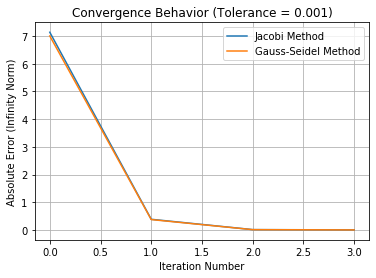

Tolerance: 0.001
  Jacobi iterations: 4
  Gauss-Seidel iterations: 4



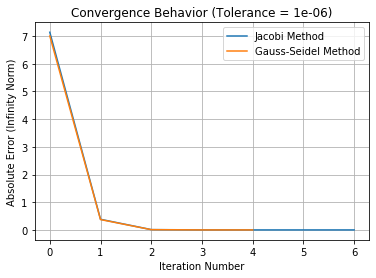

Tolerance: 1e-06
  Jacobi iterations: 7
  Gauss-Seidel iterations: 5



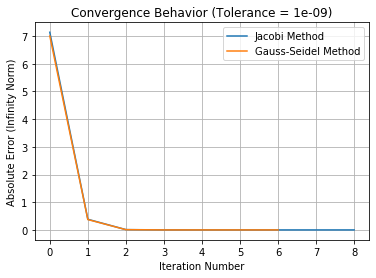

Tolerance: 1e-09
  Jacobi iterations: 9
  Gauss-Seidel iterations: 7



In [3]:
for tol in tolerances:

    x_jacobi, jacobi_iters, jacobi_errors = jacobi_method(
        A, b, x0, tol, max_steps
    )

    x_gs, gs_iters, gs_errors = gauss_seidel_method(
        A, b, x0, tol, max_steps
    )

    plt.figure()
    plt.plot(jacobi_errors, label="Jacobi Method")
    plt.plot(gs_errors, label="Gauss-Seidel Method")
    plt.xlabel("Iteration Number")
    plt.ylabel("Absolute Error (Infinity Norm)")
    plt.title(f"Convergence Behavior (Tolerance = {tol})")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Tolerance: {tol}")
    print(f"  Jacobi iterations: {jacobi_iters}")
    print(f"  Gauss-Seidel iterations: {gs_iters}\n")